In [28]:
import sys
import os
import warnings
os.environ['KMP_DUPLICATE_LIB_OK']='True'
warnings.filterwarnings('ignore')
# 获取当前工作目录


$$C=\sum_{i=1}^{n+1} \pi_i e^{r \tau} \int_{X}^{\infty} (S_T - X) \frac{1}{S_T \sigma \sqrt{2\pi}} \exp\left(-\frac{(\ln(S_T) - \mu_i)^2}{2 \sigma^2}\right) dS_T, S_T>X
$$

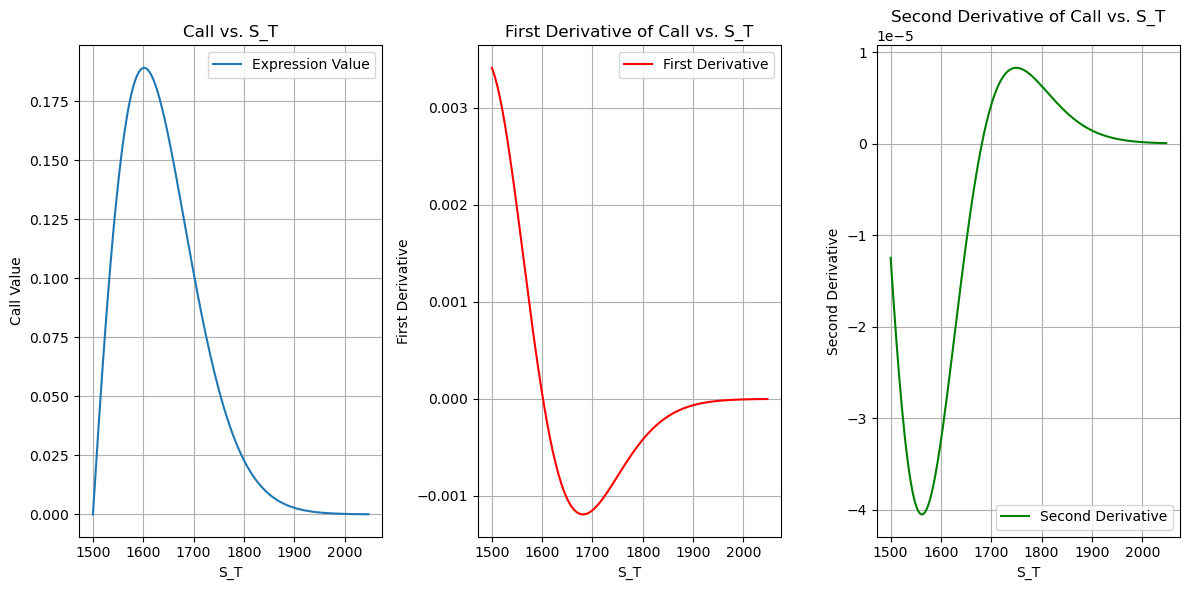

(tensor([0.0000e+00, 9.3354e-03, 1.8559e-02, 2.7654e-02, 3.6603e-02, 4.5391e-02,
         5.4004e-02, 6.2425e-02, 7.0643e-02, 7.8644e-02, 8.6415e-02, 9.3947e-02,
         1.0123e-01, 1.0825e-01, 1.1500e-01, 1.2148e-01, 1.2767e-01, 1.3358e-01,
         1.3919e-01, 1.4450e-01, 1.4951e-01, 1.5422e-01, 1.5862e-01, 1.6272e-01,
         1.6651e-01, 1.6999e-01, 1.7317e-01, 1.7605e-01, 1.7862e-01, 1.8091e-01,
         1.8290e-01, 1.8460e-01, 1.8602e-01, 1.8717e-01, 1.8804e-01, 1.8866e-01,
         1.8902e-01, 1.8913e-01, 1.8900e-01, 1.8864e-01, 1.8805e-01, 1.8726e-01,
         1.8625e-01, 1.8505e-01, 1.8366e-01, 1.8209e-01, 1.8036e-01, 1.7846e-01,
         1.7641e-01, 1.7423e-01, 1.7191e-01, 1.6947e-01, 1.6691e-01, 1.6426e-01,
         1.6150e-01, 1.5866e-01, 1.5575e-01, 1.5276e-01, 1.4971e-01, 1.4661e-01,
         1.4346e-01, 1.4027e-01, 1.3706e-01, 1.3381e-01, 1.3055e-01, 1.2728e-01,
         1.2401e-01, 1.2073e-01, 1.1746e-01, 1.1420e-01, 1.1096e-01, 1.0774e-01,
         1.0455e-01, 1.0138e

In [29]:
import torch
import matplotlib.pyplot as plt
import numpy as np

n = 25
# 从1000-1700均匀取25个数
X = np.linspace(1000, 1700, n)
T = 30
r = 1.045
d = 0.025
ST = 1365
tau = T / 365
sigma_1000 = 0.2  # 当 X = 1000 时的波动率
sigma_1700 = 0.4  # 当 X = 1700 时的波动率
sigma = 0.071

mu = np.array([
    7.304438, 6.7510858, 6.527021, 6.7932367, 6.734221, 6.7011895, 6.7597446,
    6.5170727, 6.506393, 6.7674537, 6.7137303, 6.5049725, 6.77777, 6.6301975,
    6.793338, 6.758752, 6.790524, 6.708569, 6.7933884, 6.745955, 6.7654552,
    6.547952, 6.776112, 6.507636, 6.780764, 6.7776117
])

pi = np.array([
    9.9999881e-01, 1.0457891e-06, 1.0216021e-06, 1.0415544e-06, 1.0014400e-06,
    1.0022793e-06, 1.0019197e-06, 1.0223490e-06, 1.0255023e-06, 1.0019344e-06,
    1.0026789e-06, 1.0265527e-06, 1.0012577e-06, 1.0474204e-06, 1.0439570e-06,
    1.4021799e-05, 1.0166247e-06, 1.0011702e-06, 1.0444188e-06, 1.0019169e-06,
    1.0011807e-06, 1.0467658e-06, 1.0012585e-06, 1.0461144e-06, 1.0441209e-06,
    1.0015023e-06
])

def calculate_and_plot_expression(pi, mu, sigma, X, r, tau, S_T_max, num_points=200):
    pi = torch.tensor(pi, dtype=torch.float32)
    mu = torch.tensor(mu, dtype=torch.float32)
    sigma = torch.tensor(sigma, dtype=torch.float32)
    X = torch.tensor(X, dtype=torch.float32)
    r = torch.tensor(r, dtype=torch.float32)
    tau = torch.tensor(tau, dtype=torch.float32)

    # Define the range for S_T
    S_T_range = torch.linspace(X, S_T_max, num_points)
    S_T_range.requires_grad_(True)

    # Calculate the expression
    expression_values = torch.zeros(num_points)
    for i in range(len(pi)):
        part1 = (S_T_range - X) / (S_T_range * sigma * torch.sqrt(torch.tensor(2 * np.pi)))
        part2 = torch.exp(-((torch.log(S_T_range) - mu[i])**2) / (2 * sigma**2))
        expression = pi[i] * part1 * part2 * torch.exp(-r * tau)
        expression_values = expression_values + expression

    # Compute the first derivative
    gradients = torch.autograd.grad(expression_values.sum(), S_T_range, create_graph=True)[0]

    # Compute the second derivative
    double_gradients = torch.autograd.grad(gradients.sum(), S_T_range)[0]

    # Plot the results
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.plot(S_T_range.detach().numpy(), expression_values.detach().numpy(), label='Expression Value')
    plt.title('Call vs. S_T')
    plt.xlabel('S_T')
    plt.ylabel('Call Value')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(S_T_range.detach().numpy(), gradients.detach().numpy(), label='First Derivative', color='red')
    plt.title('First Derivative of Call vs. S_T')
    plt.xlabel('S_T')
    plt.ylabel('First Derivative')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(S_T_range.detach().numpy(), double_gradients.detach().numpy(), label='Second Derivative', color='green')
    plt.title('Second Derivative of Call vs. S_T')
    plt.xlabel('S_T')
    plt.ylabel('Second Derivative')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return expression_values, gradients, double_gradients

calculate_and_plot_expression(pi, mu, sigma, 1500, r, tau, 1.5*ST)

